# 1 - Simple Pitch Analysis of Jazz Corpus

## Imports

In [532]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [1027]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import pitchanalysis_utils as pa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [954]:
metadata = g.load_metadata()

## Example: Subset

In [1174]:
subset = metadata[(metadata['workTitle'] == 'Four') | (metadata['workTitle'] == 'Blues By Five')]
subset = subset[subset['artists'].isin(['John Coltrane', 'Miles Davis'])]
subset = g.load_notes(subset)
identifier = ['artist', 'workTitle']
subset = subset.groupby(identifier, as_index=False).agg(list)
subset

,artist,workTitle,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,...,volta,chord_id,pc,note,time,fnames,rel_paths,recording_year,label,ILS
0,John Coltrane,Blues By Five,"[2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 6, ...","[2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 6, ...","[0.5, 0.625, 0.875, 0.0, 0.125, 0.375, 0.5, 0....","[1/2, 5/8, 7/8, 0, 1/8, 3/8, 1/2, 3/4, 7/8, 0,...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.125, 0.25, 0.125, 0.125, 0.25, 0.125, 0.25,...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[8, 10, 0, 0, 3, 5, 5, 8, 10, 10, 5, 8, 7, 5, ...","[Ab, Bb, C, C, Eb, F, F, Ab, Bb, Bb, F, Ab, G,...","[2.5, 2.625, 2.875, 3.0, 3.125, 3.375, 3.5, 3....","[Blues By Five - John Coltrane (Concert Key), ...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[E-7, E-7, E-7, B-7, B-7, B-7, B-7, B-7, B-7, ...","[[E-, G, B-, D-], [E-, G, B-, D-], [E-, G, B-,..."
1,John Coltrane,Four,"[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[0.625, 0.75, 0.875, 0.125, 0.25, 0.375, 0.625...","[5/8, 3/4, 7/8, 1/8, 1/4, 3/8, 5/8, 3/4, 7/8, ...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10, 0, 2, 10, 0, 2, 10, 0, 2, 5, 3, 2, 10, 0,...","[Bb, C, D, Bb, C, D, Bb, C, D, F, Eb, D, Bb, C...","[9.625, 9.75, 9.875, 10.125, 10.25, 10.375, 10...","[Four - John Coltrane (Concert Key), Four - Jo...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[E-maj7, E-maj7, E-maj7, E-maj7, E-maj7, E-maj...","[[E-, G, B-, D], [E-, G, B-, D], [E-, G, B-, D..."
2,Miles Davis,Blues By Five,"[1, 1, 1, 2, 2, 2, 2, 3, 3, 5, 5, 5, 5, 5, 5, ...","[1, 1, 1, 2, 2, 2, 2, 3, 3, 5, 5, 5, 5, 5, 5, ...","[0.0, 0.25, 0.5, 0.375, 0.5, 0.625, 0.75, 0.0,...","[0, 1/4, 1/2, 3/8, 1/2, 5/8, 3/4, 0, 1/4, 0, 1...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.25, 0.25, 0.25, 0.125, 0.125, 0.125, 0.25, ...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[10, 10, 10, 1, 2, 1, 2, 10, 10, 7, 10, 0, 10,...","[Bb, Bb, Bb, C#, D, C#, D, Bb, Bb, G, Bb, C, B...","[1.0, 1.25, 1.5, 2.375, 2.5, 2.625, 2.75, 3.0,...","[Blues By Five - Miles Davis (Concert Key), Bl...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[B-7, B-7, B-7, E-7, E-7, E-7, E-7, B-7, B-7, ...","[[B-, D, F, A-], [B-, D, F, A-], [B-, D, F, A-..."
3,Miles Davis,Four,"[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, ...","[0.625, 0.75, 0.875, 0.125, 0.25, 0.375, 0.625...","[5/8, 3/4, 7/8, 1/8, 1/4, 3/8, 5/8, 3/4, 7/8, ...","[4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, 4/4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...",...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 2, 4, 0, 2, 4, 0, 2, 4, 7, 5, 4, 0, 2, 3, ...","[C, D, E, C, D, E, C, D, E, G, F, E, C, D, Eb,...","[9.625, 9.75, 9.875, 10.125, 10.25, 10.375, 10...","[Four - Miles Davis (Concert Key), Four - Mile...","[by_Carles_Margarit, by_Carles_Margarit, by_Ca...","[1956, 1956, 1956, 1956, 1956, 1956, 1956, 195...","[Fmaj7, Fmaj7, Fmaj7, Fmaj7, Fmaj7, Fmaj7, Fma...","[[F, A, C, E], [F, A, C, E], [F, A, C, E], [F,..

In [1176]:

data = pa.create_data(subset, identifier)
pa.plot_pitch_distribution(data, identifier)

{('John Coltrane',
  'Blues By Five'): note        [Ab, Bb, C, C, Eb, F, F, Ab, Bb, Bb, F, Ab, G,...
 tpc         [-4, -2, 0, 0, -3, -1, -1, -4, -2, -2, -1, -4,...
 duration    [0.125, 0.25, 0.125, 0.125, 0.25, 0.125, 0.25,...
 Name: 0, dtype: object,
 ('John Coltrane',
  'Four'): note        [Bb, C, D, Bb, C, D, Bb, C, D, F, Eb, D, Bb, C...
 tpc         [-2, 0, 2, -2, 0, 2, -2, 0, 2, -1, -3, 2, -2, ...
 duration    [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...
 Name: 1, dtype: object,
 ('Miles Davis',
  'Blues By Five'): note        [Bb, Bb, Bb, C#, D, C#, D, Bb, Bb, G, Bb, C, B...
 tpc         [-2, -2, -2, 7, 2, 7, 2, -2, -2, 1, -2, 0, -2,...
 duration    [0.25, 0.25, 0.25, 0.125, 0.125, 0.125, 0.25, ...
 Name: 2, dtype: object,
 ('Miles Davis',
  'Four'): note        [C, D, E, C, D, E, C, D, E, G, F, E, C, D, Eb,...
 tpc         [0, 2, 4, 0, 2, 4, 0, 2, 4, 1, -1, 4, 0, 2, -3...
 duration    [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.1...
 Name: 3, dtype: object}

## Questions + next steps: 
- weigh by duration
    - Currently summing the duration then normalizing by total duration of all notes

## By Artist

In [1153]:
grouped_artists = metadata['artists'].value_counts()
subset_artists = grouped_artists.iloc[0:8].index
subset = metadata[metadata['artists'].isin(subset_artists)]
subset.head(5)

Frank Zappa      34
Bill Evans       24
Yohan Kim        12
Dexter Gordon    12
Miles Davis       8
Chet Baker        8
Bob Mintzer       7
Paul Desmond      7
Name: artists, dtype: int64

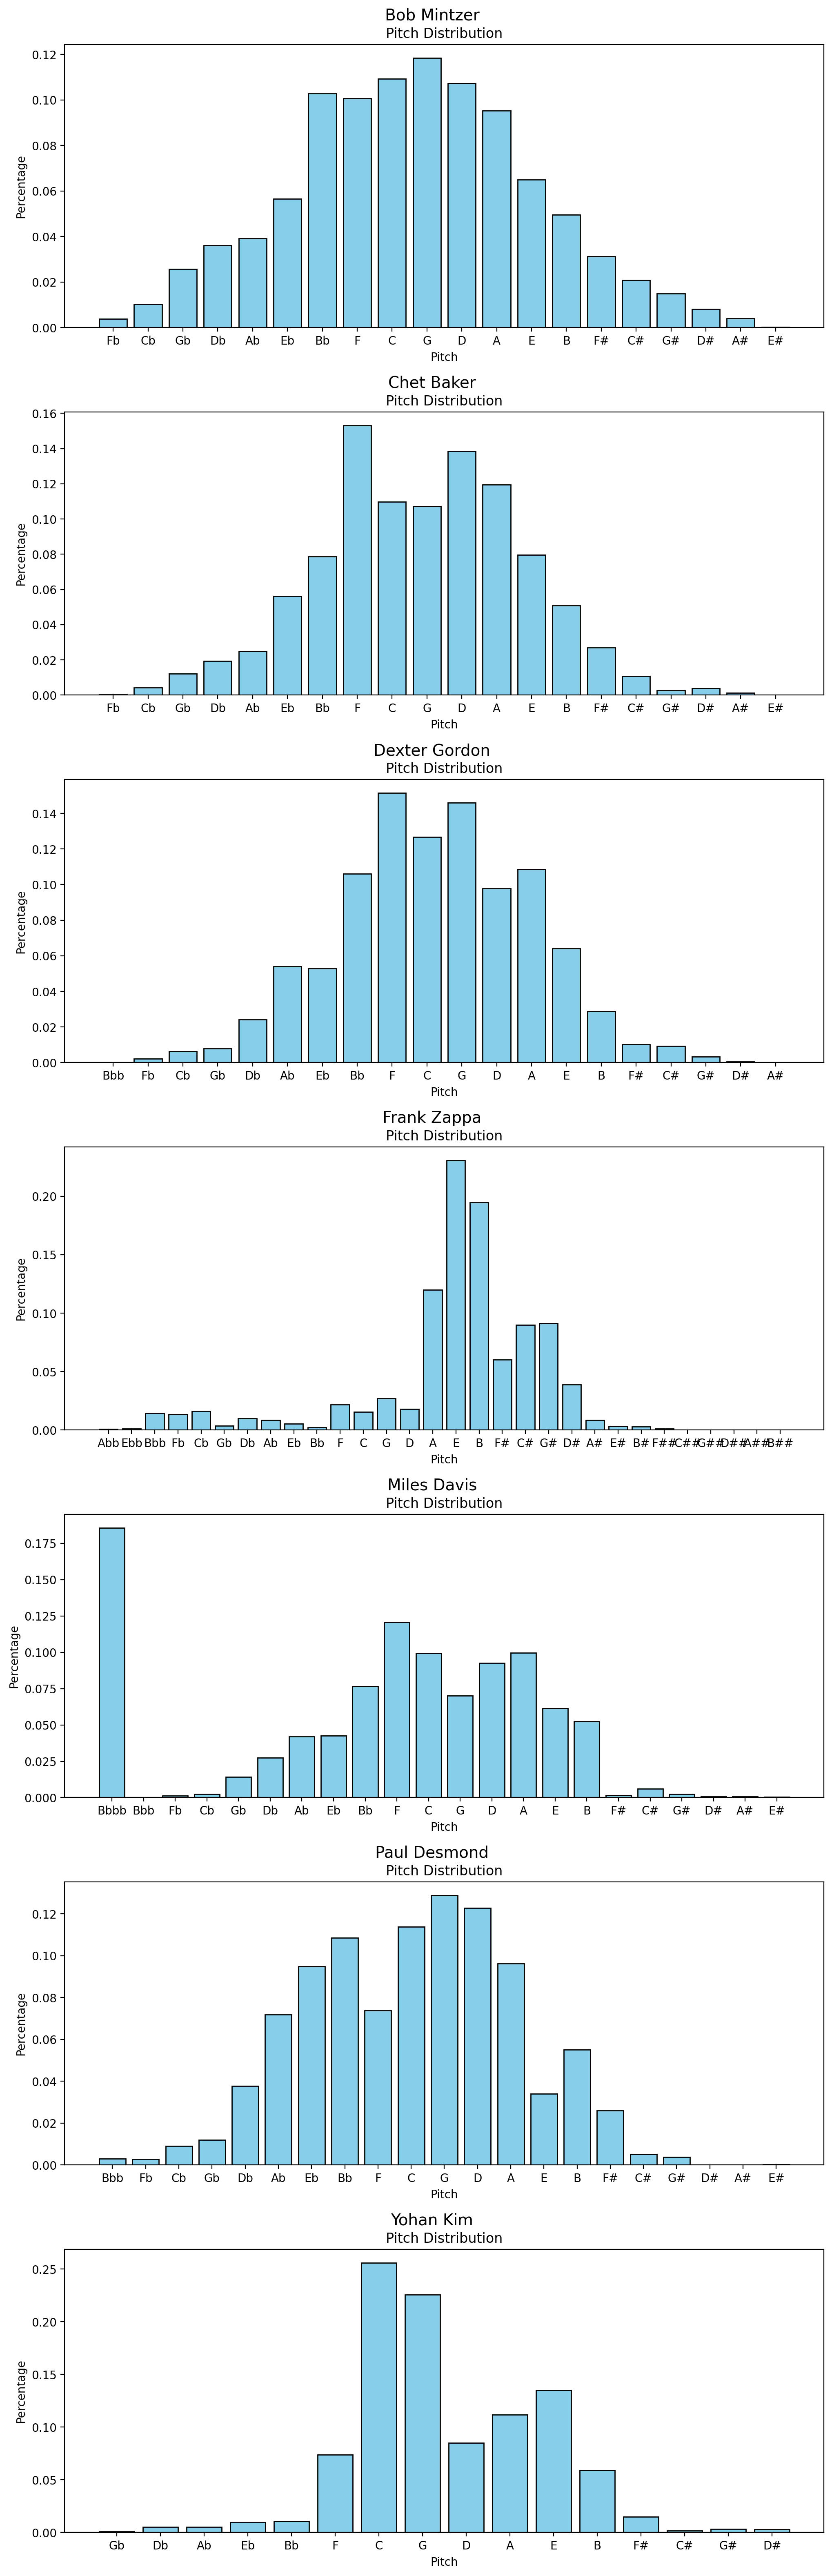

In [1158]:
subset = g.load_notes(subset)
identifier = ['artist']
subset = subset.groupby(identifier, as_index=False).agg(list)
data = pa.create_data(subset, identifier)
pa.plot_pitch_distribution(data, identifier, fig_name='0618_jazz_artist_pitch')

## By Year

In [1161]:
grouped_year = metadata['recording_year'].value_counts()
subset_year = grouped_year.iloc[0:8]
subset_year

1963    24
1956    20
2017    15
1954    11
1962    11
2014     8
2012     8
2009     8
Name: recording_year, dtype: int64

In [1163]:
subset_year = subset_year.copy().index
subset = metadata[metadata['recording_year'].isin(subset_year)]
subset.head(5)

,rel_paths,fnames,last_mc,last_mn,KeySig,TimeSig,label_count,annotated_key,composer,workTitle,...,staff_7_ambitus,staff_7_instrument,staff_8_ambitus,staff_8_instrument,staff_9_ambitus,staff_9_instrument,transcribed_instruments,transcribed_sections,transposition,year_certain
2,by_Alexander_Booker,Vulfpeck-Fugue_State,71,71,1: 0,1: 4/4,13,NaN,"Woody Goss, Jack Stratton",Fugue State,...,NaN,NaN,NaN,NaN,NaN,NaN,"ep, g, b, dr",complete,Concert Key,1
6,by_Carles_Margarit,All Of Me - Lester Young (Bb),310,310,1: 2,1: 4/4,187,NaN,"Gerald Marks, Seymour Simons",All Of Me,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,complete,Bb,1
7,by_Carles_Margarit,All The Things You Are - Bob Mintzer (Concert ...,86,86,1: -2,1: 4/4,75,NaN,"Jerome David Kern, Oscar Hammerstein",All The Things You Are,...,NaN,NaN,NaN,NaN,NaN,NaN,ts,complete,Concert Key,0
9,by_Carles_Margarit,All The Things You Are - Paul Desmond (Concert...,145,145,1: -3,1: 4/4,145,a,"Jerome David Kern, Oscar Hammerstein",All The Things You Are,...,NaN,NaN,NaN,NaN,NaN,NaN,as,solo,Concert Key,1
12,by_Carles_Margarit,Au Privave - Sonny Stitt (Concert Key),153,153,1: -1,1: 4/4,0,NaN,Charlie Parker,Au Privave,...,NaN,NaN,NaN,NaN,NaN,NaN,as,complete,Concert Key,1


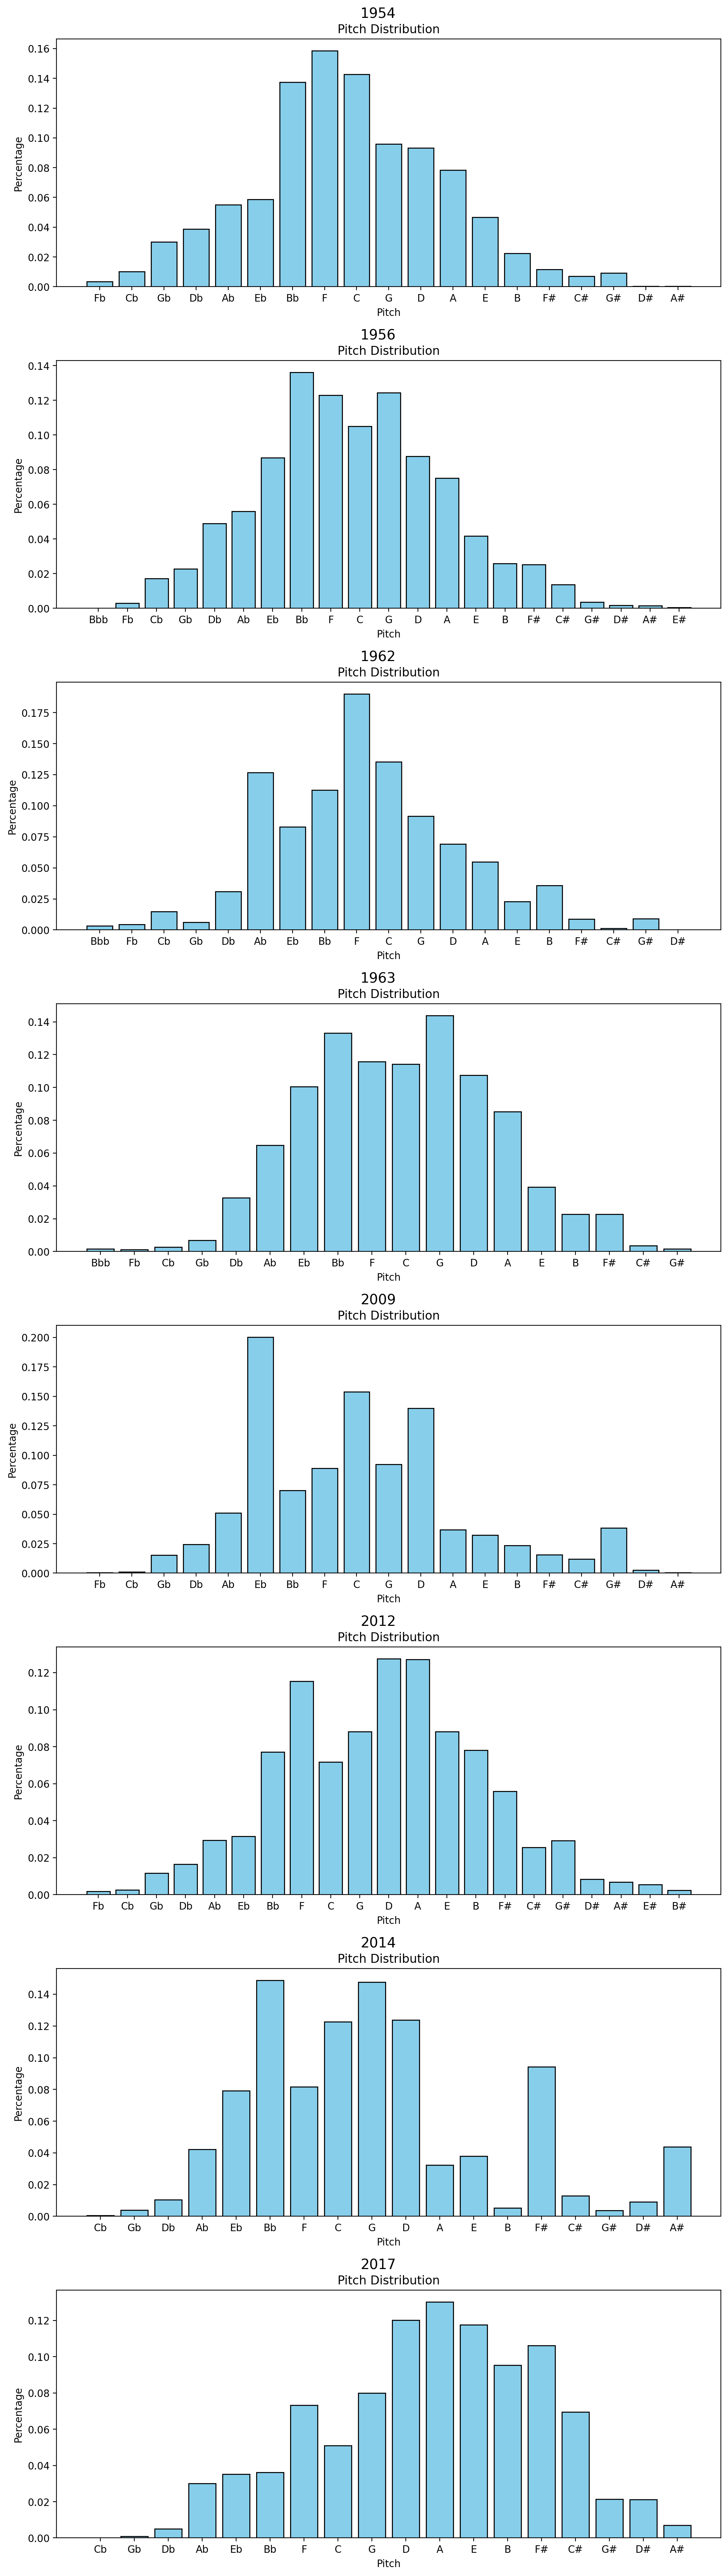

In [1165]:
subset = g.load_notes(subset)
identifier = ['recording_year']
subset = subset.groupby(identifier, as_index=False).agg(list)
data = pa.create_data(subset, identifier)
pa.plot_pitch_distribution(data, identifier, fig_name='0618_jazz_year_pitch')